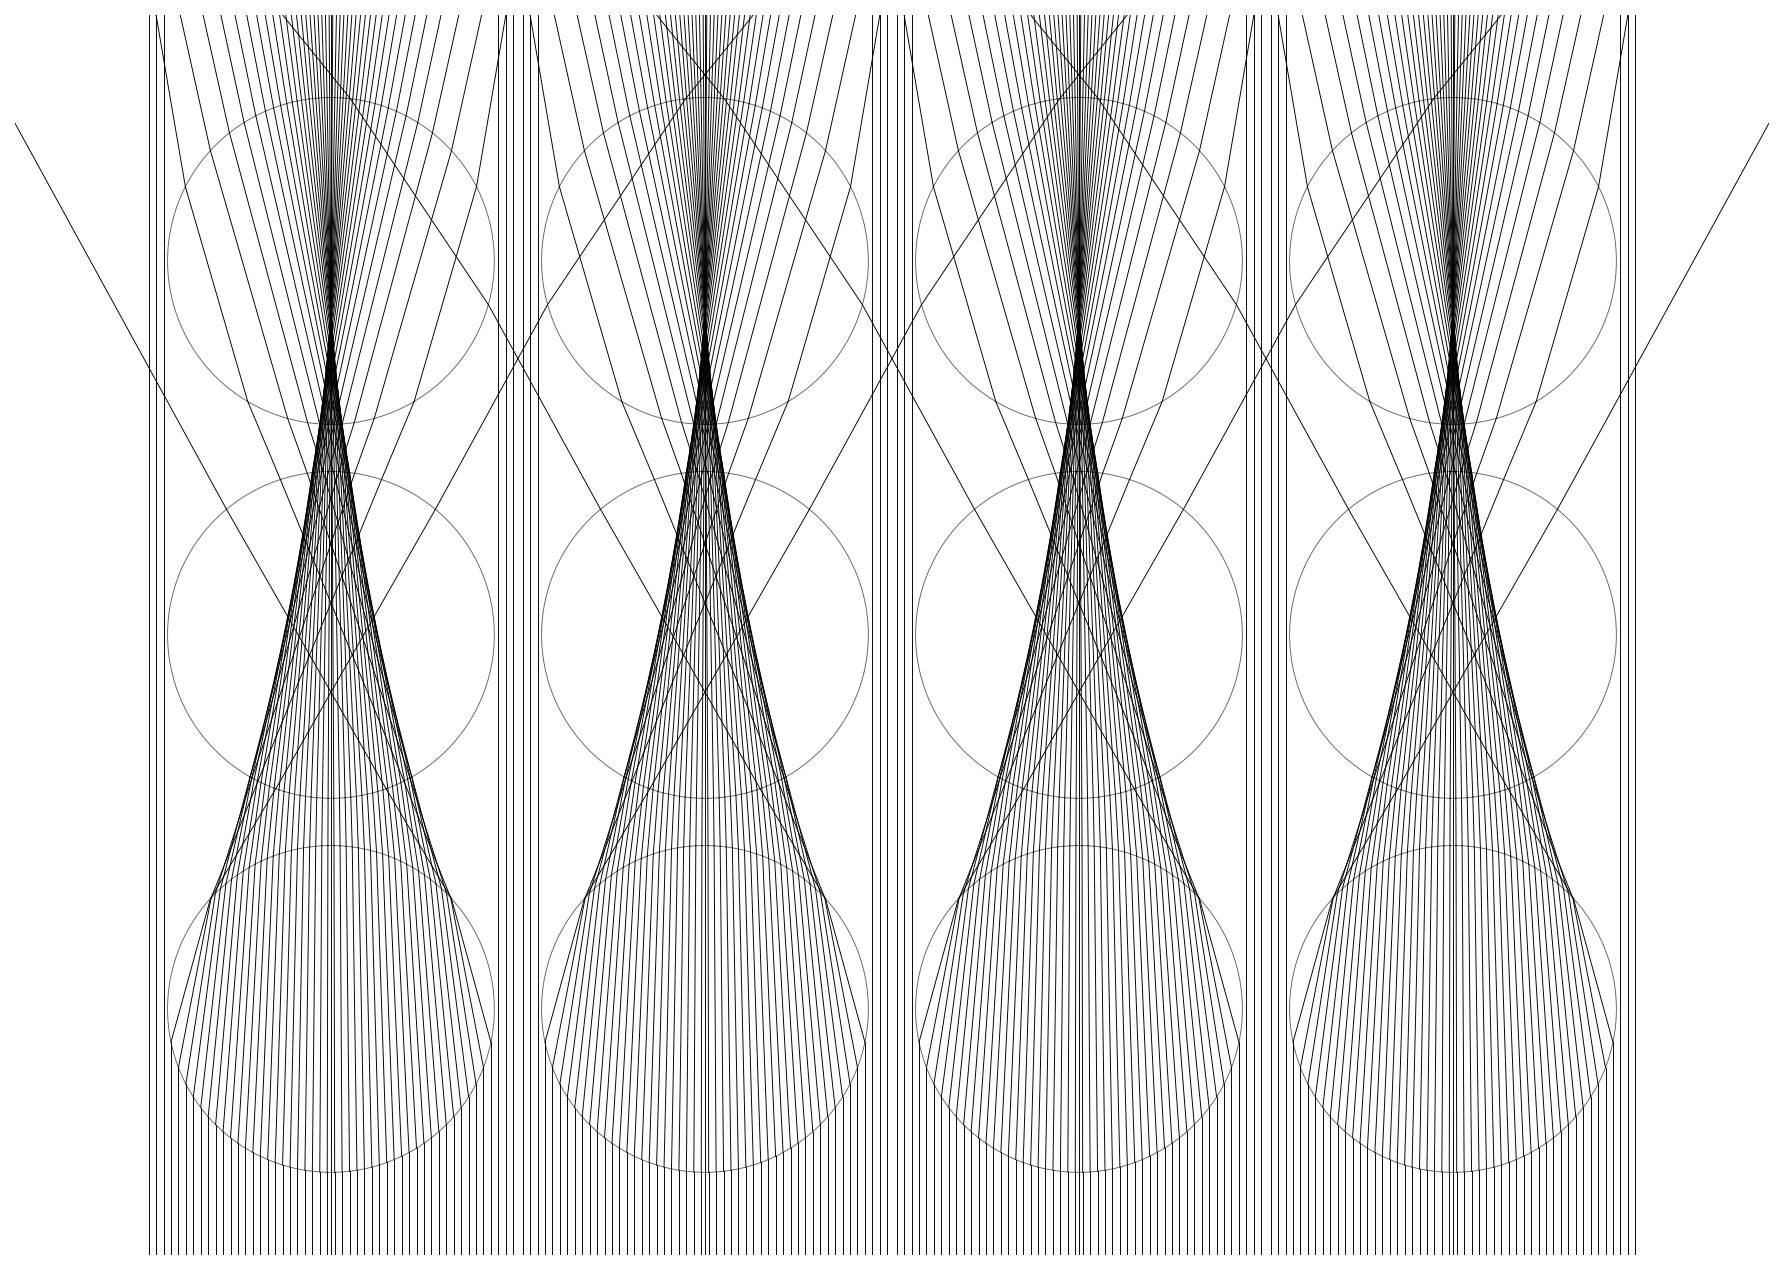

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================
# Parameters
# =========================================
# Artboard: A4 landscape in millimeters
W, H = 297.0, 210.0

# Circle grid
GRID_COLS = 4
GRID_ROWS = 3
MARGIN_X = 14.0
MARGIN_Y = 14.0
CELL_GAP = 8.0  # free space between neighboring circles

# Optics
N_OUT = 1.00
N_GLASS = 1.1  # make this your parameter

# Rays
# We place the same symmetric set of offsets around each column center.
# Include 0 so one ray goes through each circle center.
N_OFFSETS_PER_COL = 50                 # total rays = GRID_COLS * N_OFFSETS_PER_COL
OFFSET_FRAC_RANGE = 1.0                # offsets span [-1, 1] in a scaled unit (see below)
MAX_INTERACTIONS = 200
RAY_STEP_EPS = 1e-6
LINEWIDTH = 0.45
ALPHA = 1.0

# Output
SAVE_SVG = True
SVG_NAME = "05_ray_art_4x3_glass.svg"

# =========================================
# Geometry helpers
# =========================================
def build_circle_grid(cols=GRID_COLS, rows=GRID_ROWS):
    """Return list of (cx, cy, r), and also the fitted radius r."""
    avail_w = W - 2*MARGIN_X
    avail_h = H - 2*MARGIN_Y

    # total width = cols*(2r) + (cols-1)*CELL_GAP
    # total height = rows*(2r) + (rows-1)*CELL_GAP
    r_w = (avail_w - (cols - 1)*CELL_GAP) / (2*cols)
    r_h = (avail_h - (rows - 1)*CELL_GAP) / (2*rows)
    r = max(0.0, min(r_w, r_h))

    total_w = cols*(2*r) + (cols - 1)*CELL_GAP
    total_h = rows*(2*r) + (rows - 1)*CELL_GAP
    start_x = 0.5*(W - total_w) + r
    start_y = 0.5*(H - total_h) + r

    circles = []
    for j in range(rows):
        for i in range(cols):
            cx = start_x + i*(2*r + CELL_GAP)
            cy = start_y + j*(2*r + CELL_GAP)
            circles.append((cx, cy, r))
    return circles, r

def intersect_ray_circle(p, d, c, r, eps=1e-12):
    """Return smallest t > eps for intersection of ray p + t d with circle (c, r), else None."""
    m = p - c
    b = np.dot(m, d)
    cterm = np.dot(m, m) - r*r
    disc = b*b - cterm
    if disc < 0:
        return None
    sqrt_disc = np.sqrt(disc)
    t1 = -b - sqrt_disc
    t2 = -b + sqrt_disc
    ts = [t for t in (t1, t2) if t > eps]
    return min(ts) if ts else None

def intersect_ray_box(p, d, xmin, xmax, ymin, ymax, eps=1e-12):
    """Smallest t > eps to hit any edge of the box, else None."""
    ts = []
    if abs(d[0]) > eps:
        for x in (xmin, xmax):
            t = (x - p[0]) / d[0]
            y = p[1] + t*d[1]
            if t > eps and ymin - eps <= y <= ymax + eps:
                ts.append(t)
    if abs(d[1]) > eps:
        for y in (ymin, ymax):
            t = (y - p[1]) / d[1]
            x = p[0] + t*d[0]
            if t > eps and xmin - eps <= x <= xmax + eps:
                ts.append(t)
    return min(ts) if ts else None

def point_in_circle(pt, circle):
    cx, cy, r = circle
    return (pt[0] - cx)**2 + (pt[1] - cy)**2 <= r*r

# =========================================
# Refraction and reflection
# =========================================
def refract(d, n, n1, n2):
    """
    Snell in vector form. If TIR occurs, return reflected direction.
    d: unit incident direction
    n: unit surface normal pointing from inside to outside (outward)
    """
    d = d / np.linalg.norm(d)
    n = n / np.linalg.norm(n)
    cos_i = -np.dot(n, d)
    if cos_i < 0:
        n = -n
        cos_i = -np.dot(n, d)
    eta = n1 / n2
    k = 1.0 - eta**2 * (1.0 - cos_i**2)
    if k < 0.0:
        # total internal reflection
        r = d + 2.0*cos_i*n
        return False, r / np.linalg.norm(r)
    t = eta*d + (eta*cos_i - np.sqrt(k))*n
    return True, t / np.linalg.norm(t)

# =========================================
# Tracing
# =========================================
def trace_ray(p0, d0, circles, n_out, n_in, max_interactions, bounds):
    xmin, xmax, ymin, ymax = bounds
    segments = []
    p = np.array(p0, dtype=float)
    d = np.array(d0, dtype=float) / np.linalg.norm(d0)

    # identify initial medium
    inside_idx = None
    for idx, circ in enumerate(circles):
        if point_in_circle(p, circ):
            inside_idx = idx
            break

    for _ in range(max_interactions):
        # find nearest circle boundary hit
        hit_t, hit_idx = None, None
        if inside_idx is None:
            for idx, circ in enumerate(circles):
                t = intersect_ray_circle(p, d, np.array(circ[:2]), circ[2])
                if t is not None and (hit_t is None or t < hit_t):
                    hit_t, hit_idx = t, idx
        else:
            circ = circles[inside_idx]
            t = intersect_ray_circle(p, d, np.array(circ[:2]), circ[2])
            if t is not None:
                hit_t, hit_idx = t, inside_idx

        # board exit time
        t_box = intersect_ray_box(p, d, xmin, xmax, ymin, ymax)

        # leave board before any boundary
        if hit_t is None or (t_box is not None and t_box < hit_t):
            if t_box is not None:
                p_next = p + t_box*d
                segments.append((p.copy(), p_next.copy()))
            break

        # go to boundary
        p_hit = p + hit_t*d
        segments.append((p.copy(), p_hit.copy()))

        # surface normal (outward from circle)
        cx, cy, r = circles[hit_idx]
        n = (p_hit - np.array([cx, cy])) / r

        # current and next indices
        if inside_idx is None:
            n1, n2 = n_out, n_in
        else:
            n1, n2 = n_in, n_out

        did_refract, d_new = refract(d, n, n1, n2)
        if did_refract:
            inside_idx = hit_idx if inside_idx is None else None
        # advance a hair to avoid self-hit, continue
        p = p_hit + RAY_STEP_EPS * d_new
        d = d_new

        # sanity check
        if not (xmin - 1e-9 <= p[0] <= xmax + 1e-9 and ymin - 1e-9 <= p[1] <= ymax + 1e-9):
            break

    return segments

# =========================================
# Rays arranged symmetrically per column
# =========================================
def make_symmetric_rays(circles, cols=GRID_COLS, rows=GRID_ROWS, offsets_per_col=N_OFFSETS_PER_COL,
                        offset_frac_range=OFFSET_FRAC_RANGE):
    """
    Build rays so that for each column, the same symmetric set of x-offsets is used
    around the column centers. That ensures no phasing and that one ray crosses
    every circle center (offset 0).
    """
    # get unique x centers for columns, and y centers for rows
    # circles are ordered row-major: rows of cols
    centers = np.array([[c[0], c[1]] for c in circles])
    xs = np.unique(centers[:, 0])
    ys = np.unique(centers[:, 1])

    # choose an offset span in mm that is safe (does not reach neighboring cells)
    # half the clear space between circle edge and cell boundary is a robust choice.
    # compute circle radius from the first circle
    r = circles[0][2]
    # the minimum half-gap to neighbors horizontally
    half_clear_x = 0.5 * CELL_GAP
    # do not exceed radius plus some fraction of the clear half-gap
    offset_span = r + 0.8 * half_clear_x

    # build symmetric offsets with 0 included
    # offsets range in [-offset_span, offset_span]
    offsets = np.linspace(-offset_frac_range, offset_frac_range, offsets_per_col) * offset_span
    # ensure exact 0 is present (in case of even count, insert it)
    if not np.isclose(offsets, 0.0).any():
        offsets = np.sort(np.append(offsets, 0.0))

    p0_list = []
    d0_list = []

    # vertical direction up
    d0 = np.array([0.0, 1.0])

    # rays start at y = 0 (bottom edge), at x = x_center + offset for each column
    for x_center in xs:
        for dx in offsets:
            x = x_center + dx
            if 0.0 <= x <= W:
                p0_list.append(np.array([x, 0.0]))
                d0_list.append(d0.copy())

    return p0_list, d0_list

# =========================================
# Run
# =========================================
circles, fitted_r = build_circle_grid(GRID_COLS, GRID_ROWS)
bounds = (0.0, W, 0.0, H)

# build symmetric rays per column
p0s, d0s = make_symmetric_rays(circles, GRID_COLS, GRID_ROWS,
                               offsets_per_col=N_OFFSETS_PER_COL,
                               offset_frac_range=OFFSET_FRAC_RANGE)

# trace all rays
all_segments = []
for p0, d0 in zip(p0s, d0s):
    segs = trace_ray(p0, d0, circles, N_OUT, N_GLASS, MAX_INTERACTIONS, bounds)
    all_segments.append(segs)

# =========================================
# Plot
# =========================================
fig, ax = plt.subplots(figsize=(W/25.4, H/25.4), dpi=150)
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(0, W)
ax.set_ylim(0, H)
ax.axis("off")

# draw circles
for cx, cy, r in circles:
    circ = plt.Circle((cx, cy), r, fill=False, linewidth=0.45, alpha=0.6)
    ax.add_patch(circ)

# draw rays
for segs in all_segments:
    for a, b in segs:
        ax.plot([a[0], b[0]], [a[1], b[1]], color="black", lw=LINEWIDTH, alpha=ALPHA)

plt.tight_layout(pad=0)
if SAVE_SVG:
    plt.savefig(SVG_NAME, format="svg", bbox_inches="tight", pad_inches=0)


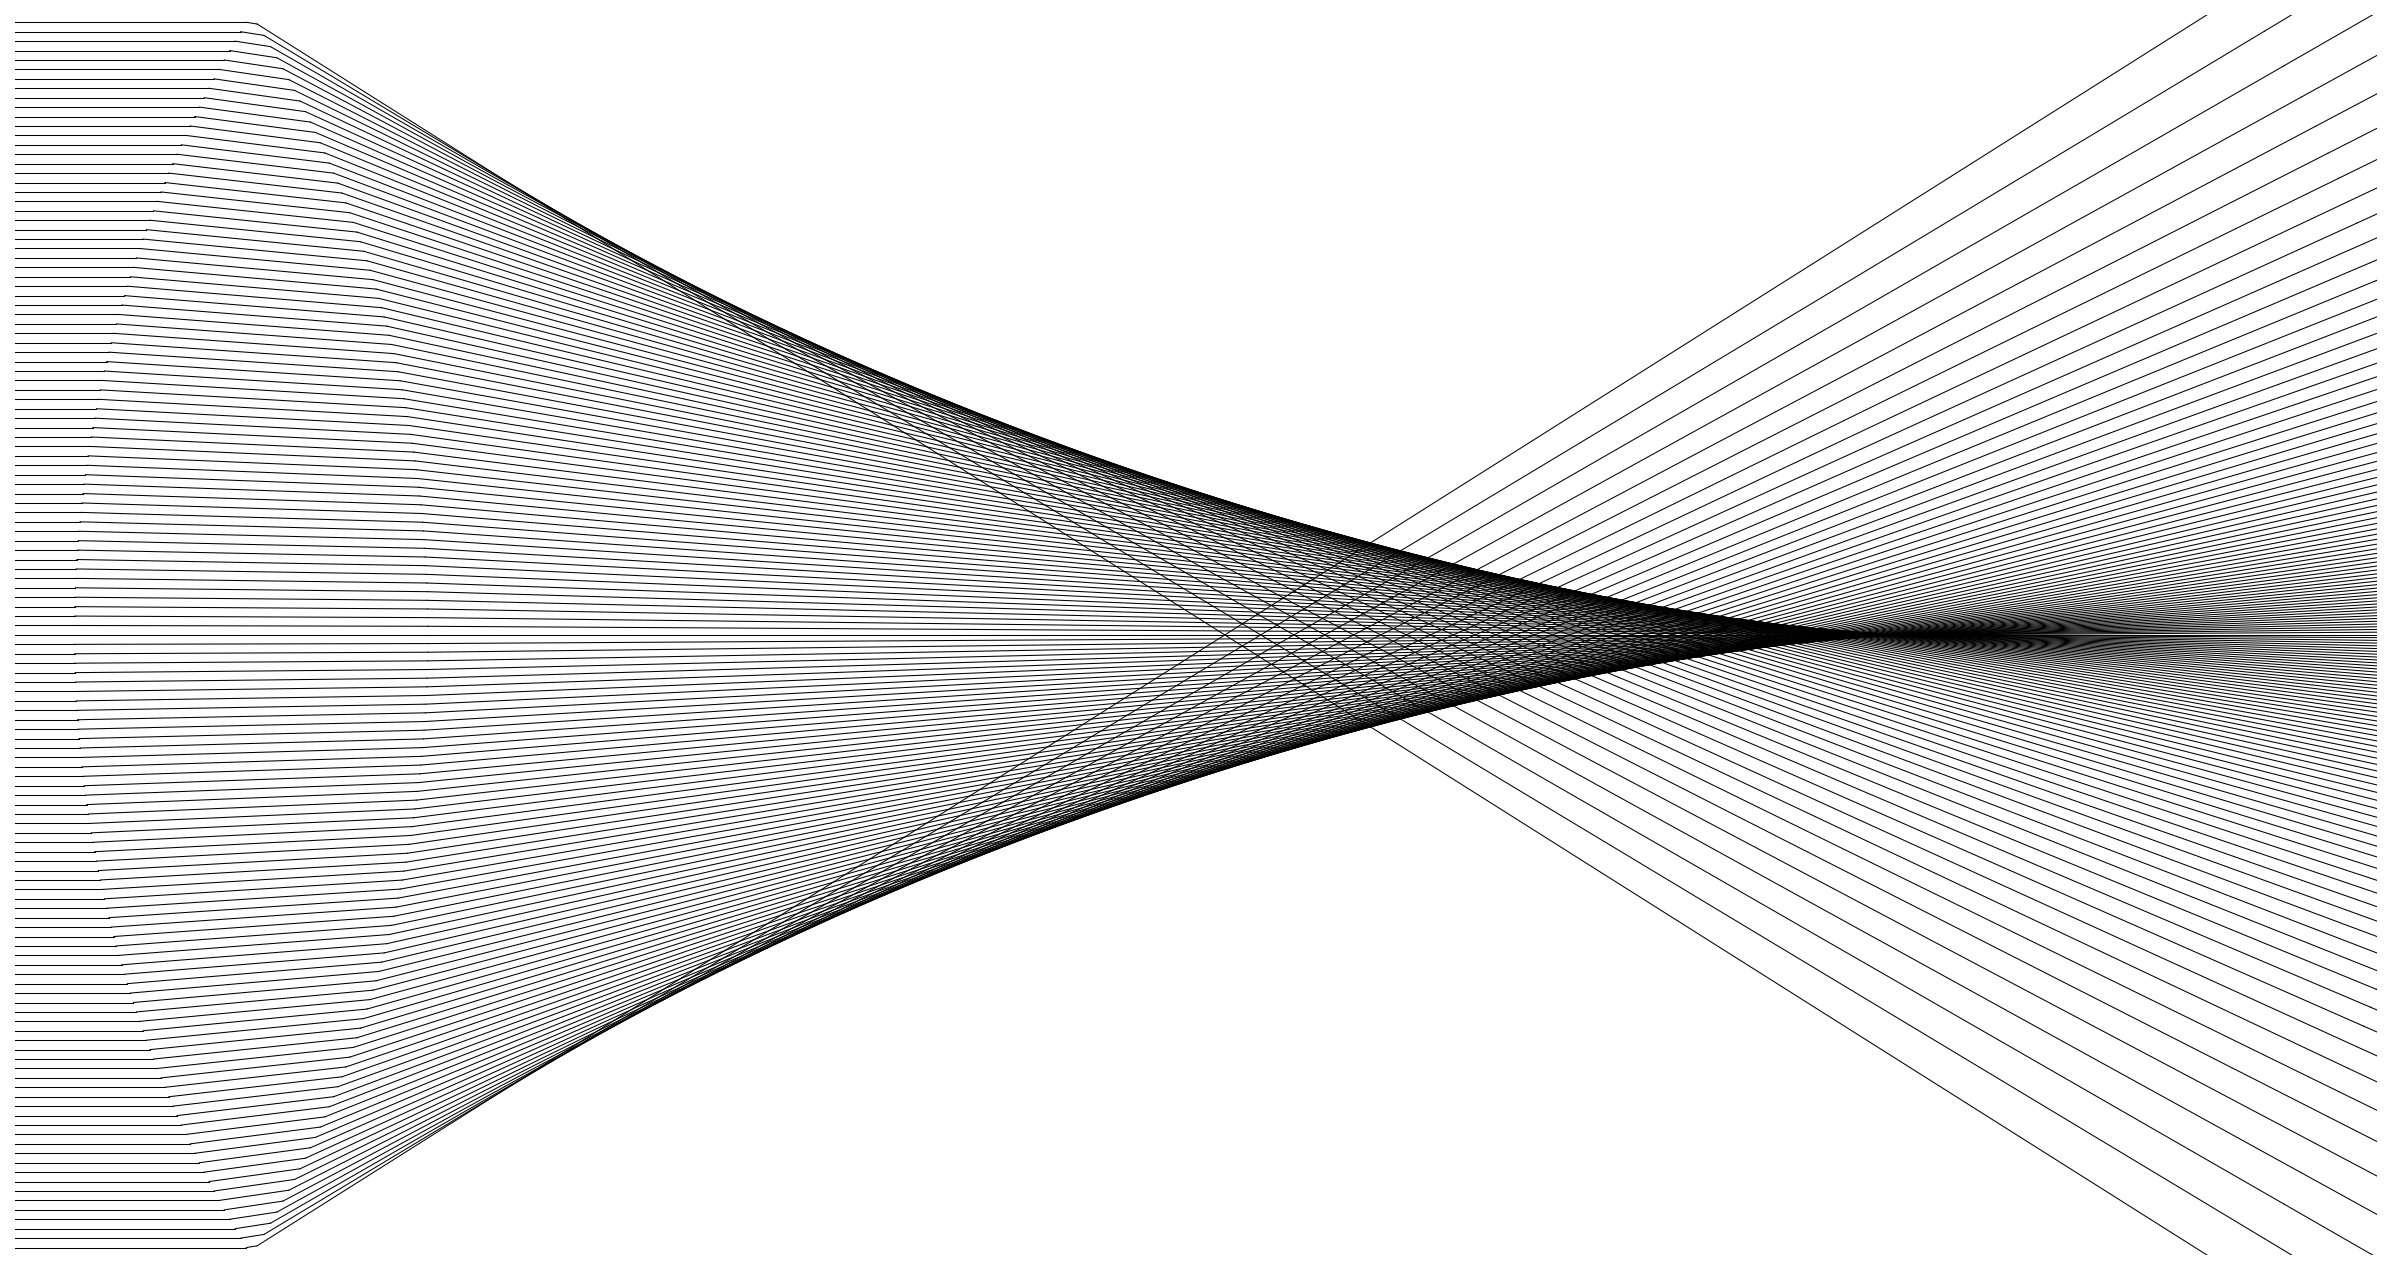

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Artboard (mm)
# ==============================
W, H = 400.0, 210.0   # A4-ish, your custom width kept

# ==============================
# Lens parameters
# ==============================
# Lens optical center (fractions of board size, 0..1)
LENS_CX_FRAC = 0.1
LENS_CY_FRAC = 0.50

# Sphere radius that defines each surface
SPHERE_R_MM   = 1.9* H/2      # or set SPHERE_R_FRAC below
SPHERE_R_FRAC = None       # if not None: radius = SPHERE_R_FRAC * min(W, H)

# Separation between the two sphere centers (as a fraction of the sphere radius).
# 0 < SEP_FRAC < 2 gives a proper "lens" intersection of the two discs.
SEP_FRAC = 1.7

# Indices
N_OUTSIDE = 1.00
N_LENS    = 1.38

# Rays
N_RAYS = 301               # odd -> center ray; even -> no center ray
OFFSET_FRAC_RANGE = 1.2    # offsets in units of lens semi-aperture proxy (we use R here)
MAX_INTERACTIONS = 40
RAY_STEP_EPS = 1e-6
RAY_LW = 0.5
RAY_ALPHA = 1.0

# Visuals
DRAW_LENS_OUTLINE = False  # set True to draw the two arcs
ARC_LW = 0.5
SAVE_SVG = True
SVG_NAME = "05_spherical_lens_raytrace_DENSE.svg"

# ==============================
# Geometry helpers
# ==============================
def lens_params():
    """Return centers of the two spheres (left, right) and radius R."""
    R = SPHERE_R_MM if SPHERE_R_FRAC is None else SPHERE_R_FRAC * min(W, H)
    cx = LENS_CX_FRAC * W
    cy = LENS_CY_FRAC * H
    # two sphere centers separated along x by SEP_FRAC * R to make a biconvex lens
    c_left  = np.array([cx - (SEP_FRAC * R) / 2.0, cy], dtype=float)
    c_right = np.array([cx + (SEP_FRAC * R) / 2.0, cy], dtype=float)
    return c_left, c_right, float(R)

def intersect_ray_circle(p, d, c, r, eps=1e-12):
    """Smallest t > eps for p + t d intersecting circle centered at c with radius r, else None."""
    m = p - c
    b = np.dot(m, d)
    cterm = np.dot(m, m) - r*r
    disc = b*b - cterm
    if disc < 0:
        return None
    s = np.sqrt(disc)
    t1 = -b - s
    t2 = -b + s
    ts = [t for t in (t1, t2) if t > eps]
    return min(ts) if ts else None

def intersect_ray_box(p, d, xmin, xmax, ymin, ymax, eps=1e-12):
    """Smallest t > eps to hit any box boundary, else None."""
    ts = []
    if abs(d[0]) > eps:
        for x in (xmin, xmax):
            t = (x - p[0]) / d[0]
            y = p[1] + t*d[1]
            if t > eps and ymin - eps <= y <= ymax + eps:
                ts.append(t)
    if abs(d[1]) > eps:
        for y in (ymin, ymax):
            t = (y - p[1]) / d[1]
            x = p[0] + t*d[0]
            if t > eps and xmin - eps <= x <= xmax + eps:
                ts.append(t)
    return min(ts) if ts else None

def inside_circle(pt, c, r):
    return np.dot(pt - c, pt - c) <= r*r

# ==============================
# Snell refraction
# ==============================
def refract(d, n, n1, n2):
    """
    d: unit incident direction
    n: unit normal pointing from inside to outside of the object at the interface
    Returns (did_refract, new_dir). If TIR, returns reflected direction with did_refract=False.
    """
    d = d / np.linalg.norm(d)
    n = n / np.linalg.norm(n)
    cos_i = -np.dot(n, d)
    if cos_i < 0:
        n = -n
        cos_i = -np.dot(n, d)
    eta = n1 / n2
    k = 1.0 - eta**2 * (1.0 - cos_i**2)
    if k < 0.0:
        r = d + 2.0*cos_i*n
        return False, r / np.linalg.norm(r)
    t = eta*d + (eta*cos_i - np.sqrt(k))*n
    return True, t / np.linalg.norm(t)

# ==============================
# Lens region logic (intersection of two disks)
# ==============================
def lens_membership(pt, cL, cR, R):
    """Return booleans: inside_left, inside_right, inside_lens (both)."""
    inL = inside_circle(pt, cL, R)
    inR = inside_circle(pt, cR, R)
    return inL, inR, (inL and inR)

def next_interface_hit(p, d, cL, cR, R, inside_left, inside_right, inside_both):
    """
    Find the next boundary along the ray that changes membership of the lens region.
    Returns (t_hit, which, n_vec, entering), where:
        which in {"left","right"} which circle boundary is hit,
        n_vec is the interface normal pointing from inside_lens to outside (for Snell),
        entering is True if crossing goes from outside_lens to inside_lens.
    If the nearest circle hit does not change inside_both, we return its t plus a flag 'which' but with n_vec=None
    to signal "advance without refraction".
    If no circle before the box, returns (None, None, None, None).
    """
    tL = intersect_ray_circle(p, d, cL, R)
    tR = intersect_ray_circle(p, d, cR, R)

    # pick nearest circle hit
    candidates = []
    if tL is not None:
        candidates.append(("left", tL))
    if tR is not None:
        candidates.append(("right", tR))
    if not candidates:
        return None, None, None, None
    which, t_hit = min(candidates, key=lambda kv: kv[1])

    # compute membership after crossing that circle only
    if which == "left":
        inL_new = not inside_left
        inR_new = inside_right
        c_hit = cL
    else:
        inL_new = inside_left
        inR_new = not inside_right
        c_hit = cR

    inside_both_new = inL_new and inR_new

    # normal at hit (outward from the circle we hit)
    p_hit = p + t_hit * d
    n_circle_out = (p_hit - c_hit) / R

    if inside_both_new != inside_both:
        # This circle boundary is a true interface of the lens region.
        # For Snell we need normal pointing from inside_lens to outside_lens.
        # If currently inside_both, outward normal is correct. If currently outside_both, we still
        # pass the outward normal; refract() will flip if needed to make cos_i >= 0.
        entering = (not inside_both) and inside_both_new
        return t_hit, which, n_circle_out, entering
    else:
        # Crossing this circle does not change lens medium. Advance without refraction.
        return t_hit, which, None, None

# ==============================
# Tracing through the lens intersection region
# ==============================
def trace_ray_lens(p0, d0, cL, cR, R, n_out, n_lens, bounds, max_interactions=40):
    xmin, xmax, ymin, ymax = bounds
    segments = []
    p = np.array(p0, dtype=float)
    d = np.array(d0, dtype=float) / np.linalg.norm(d0)

    # initial membership
    inL, inR, inLens = lens_membership(p, cL, cR, R)

    for _ in range(max_interactions):
        # time to box boundary
        t_box = intersect_ray_box(p, d, xmin, xmax, ymin, ymax)

        # time to next relevant circle boundary
        t_hit, which, n_vec, entering = next_interface_hit(p, d, cL, cR, R, inL, inR, inLens)

        # leave board before any circle
        if t_hit is None or (t_box is not None and t_box < t_hit):
            if t_box is not None:
                p2 = p + t_box*d
                segments.append((p.copy(), p2.copy()))
            break

        # advance to the circle boundary
        p_hit = p + t_hit*d
        segments.append((p.copy(), p_hit.copy()))

        # update circle membership flags for the circle we crossed
        if which == "left":
            inL = not inL
        else:
            inR = not inR
        inLens_new = inL and inR

        if n_vec is None:
            # Not an interface of the lens medium: keep direction
            p = p_hit + RAY_STEP_EPS * d
            inLens = inLens_new
            # keep marching
            continue

        # Interface: choose indices based on entering/exiting lens region
        if inLens:  # we were inside lens, now we will leave
            n1, n2 = n_lens, n_out
        else:       # we were outside, now we will enter
            n1, n2 = n_out, n_lens

        did_refract, d_new = refract(d, n_vec, n1, n2)
        # If TIR happens on exit (possible for n_lens > n_out), stay in same region.
        if did_refract:
            inLens = inLens_new
        # advance a hair and continue
        p = p_hit + RAY_STEP_EPS * d_new
        d = d_new

        # safety
        if not (xmin - 1e-9 <= p[0] <= xmax + 1e-9 and ymin - 1e-9 <= p[1] <= ymax + 1e-9):
            break

    return segments

# ==============================
# Uniform, symmetric offsets
# ==============================
def uniform_symmetric_offsets(n_rays, span):
    if n_rays <= 1:
        return np.array([0.0])
    if n_rays % 2 == 1:
        return np.linspace(-span, span, n_rays)
    else:
        step = 2*span / n_rays
        k = np.arange(n_rays)
        return (k - (n_rays/2 - 0.5)) * step

def make_parallel_rays_from_left(cy, semi_span, n_rays):
    """
    Rays start at x=0 moving right, with y positions cy + offsets, offsets uniform and symmetric.
    semi_span controls the total vertical half-span of the bundle.
    """
    offsets = uniform_symmetric_offsets(n_rays, span=semi_span)
    y_positions = cy + offsets
    p0s = [np.array([0.0, y]) for y in y_positions if 0.0 <= y <= H]
    d0s = [np.array([1.0, 0.0]) for _ in p0s]
    return p0s, d0s

# ==============================
# Run
# ==============================
cL, cR, R = lens_params()
bounds = (0.0, W, 0.0, H)

# Choose a vertical half-span for the ray bundle.
# Using OFFSET_FRAC_RANGE * R makes the bundle wide enough to show aberrations.
semi_span = OFFSET_FRAC_RANGE * R
p0s, d0s = make_parallel_rays_from_left(cy=LENS_CY_FRAC * H, semi_span=semi_span, n_rays=N_RAYS)

# Trace all rays
all_segments = []
for p0, d0 in zip(p0s, d0s):
    segs = trace_ray_lens(
        p0, d0,
        cL, cR, R,
        n_out=N_OUTSIDE,
        n_lens=N_LENS,
        bounds=bounds,
        max_interactions=MAX_INTERACTIONS,
    )
    all_segments.append(segs)

# ==============================
# Plot
# ==============================
fig, ax = plt.subplots(figsize=(W/25.4, H/25.4), dpi=150)
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(0, W)
ax.set_ylim(0, H)
ax.axis("off")

# Optional: draw the two spherical arcs
if DRAW_LENS_OUTLINE:
    theta = np.linspace(0, 2*np.pi, 800)
    for c in (cL, cR):
        ax.plot(c[0] + R*np.cos(theta), c[1] + R*np.sin(theta), lw=ARC_LW, color="black", alpha=0.4)

# Rays
for segs in all_segments:
    for a, b in segs:
        ax.plot([a[0], b[0]], [a[1], b[1]], color="black", lw=RAY_LW, alpha=RAY_ALPHA)

plt.tight_layout(pad=0)
if SAVE_SVG:
    plt.savefig(SVG_NAME, format="svg", bbox_inches="tight", pad_inches=0)


candidate  k*=-2.2059, A4*=5.000e-07, metric=1.2867 mm
refined t*=1.006 -> k=-2.2183, A4=5.028e-07, metric=1.2865 mm
lens 1/5: frac=0.000, k=-0.0000, A4=0.000e+00, metric=10.7124 mm
lens 2/5: frac=0.100, k=-0.2218, A4=5.028e-08, metric=8.3526 mm
lens 3/5: frac=0.200, k=-0.4437, A4=1.006e-07, metric=6.6054 mm
lens 4/5: frac=0.300, k=-0.6655, A4=1.508e-07, metric=5.2504 mm
lens 5/5: frac=0.400, k=-0.8873, A4=2.011e-07, metric=4.1698 mm


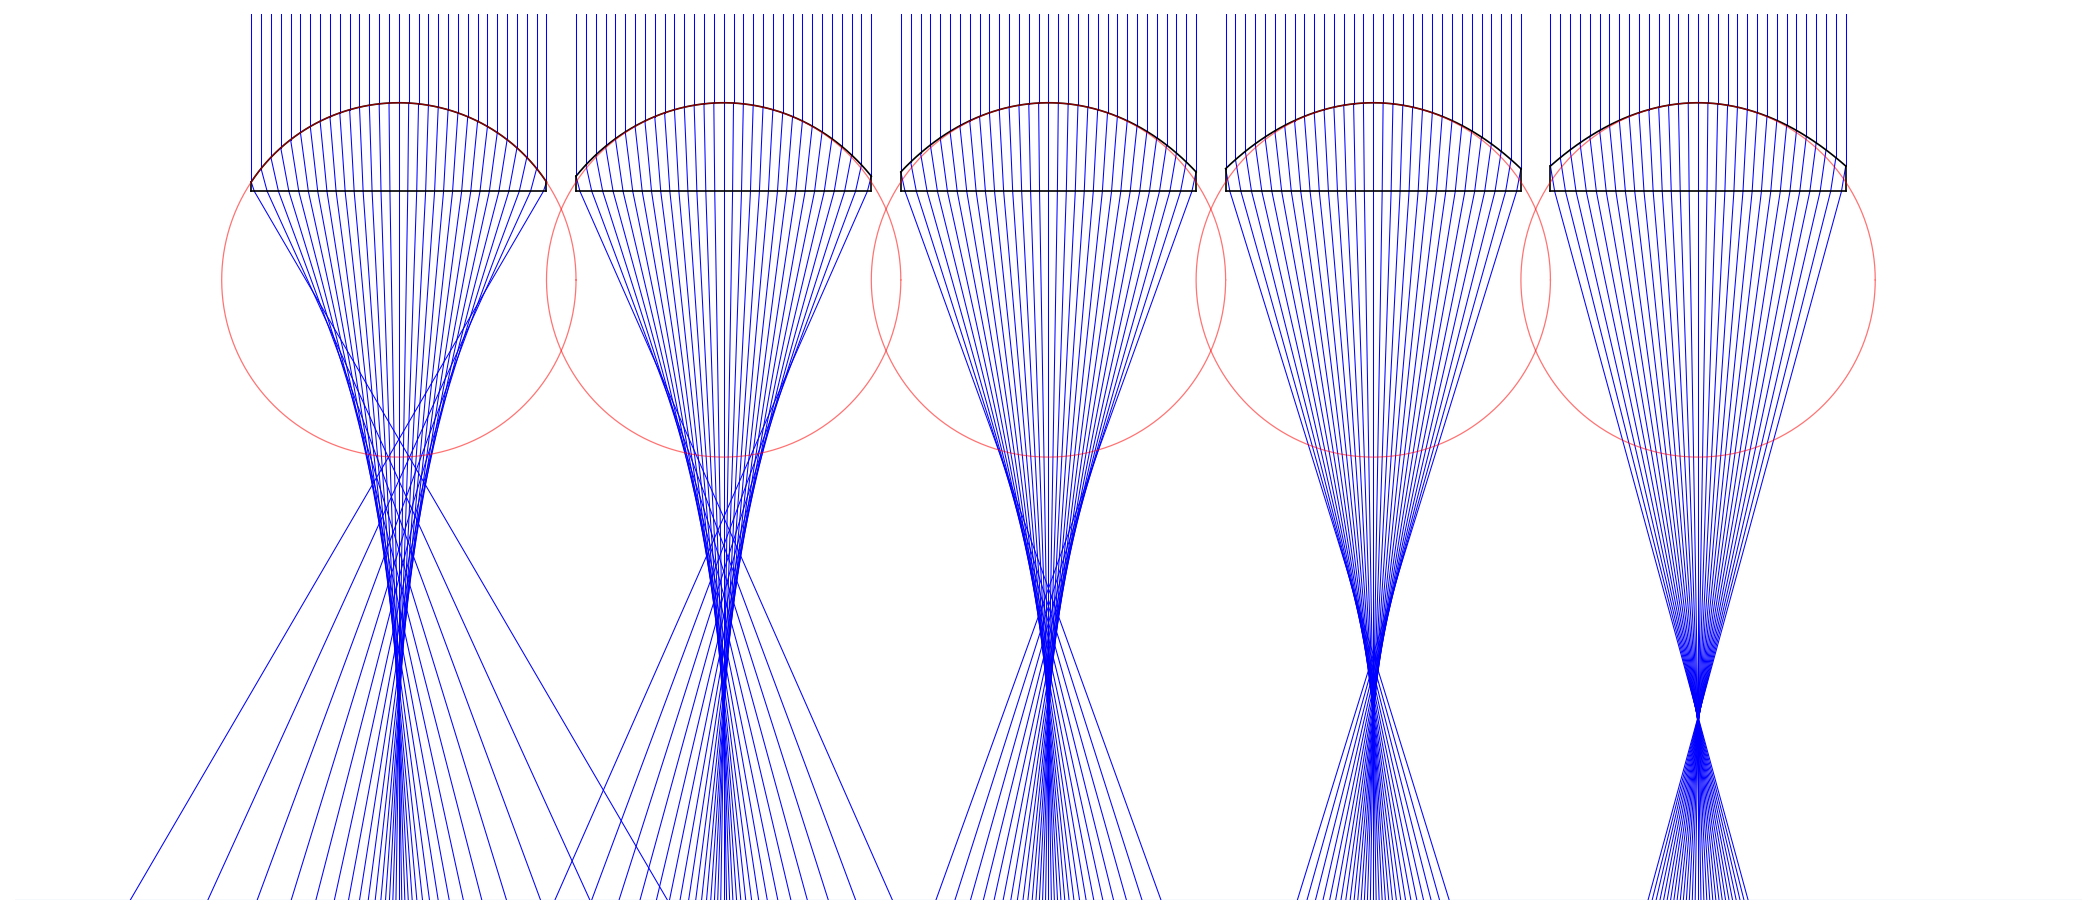

In [110]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Page and output (A4 landscape)
# ==============================
W, H = 350.0, 150.0
DPI = 150
SAVE_SVG = True
SVG_NAME = "05_asphere.svg"

# ==============================
# Geometry & optics
# ==============================
N_OUT = 1.00
N_LENS = 1.60
FOCAL_LEN = 120.0     # plane where we evaluate the spot
THICKNESS = 15.0
APERTURE_RADIUS = 25.0
R_FRONT = 30.0

# ==============================
# Layout
# ==============================
N_LENSES = 5
SIDE_MARGIN = 1.0
GAP_BETWEEN = 5.0
ROW_Y = H * 0.90

# ==============================
# Rays & drawing
# ==============================
RAYS_PER_LENS = 31
RAY_LW = 0.5
OUTLINE_LW = 0.8
FOCAL_LINE_LW = 0.6
CIRCLE_LW = 0.6
CIRCLE_ALPHA = 0.55

# ==============================
# Optimizer params
# ==============================
K_BOUNDS = (-20.0, 2.0)
A4_BOUNDS = (-5e-7, 5e-7)
INIT_K  = 0.0
INIT_A4 = 0.0
INIT_DK = 2.0
INIT_DA = 2e-7
MIN_DK  = 1e-3
MIN_DA  = 1e-10
MAX_ITERS = 80
GRID_STEPS_K = 9
GRID_STEPS_A4 = 9

# ==============================
# Asphere and Snell
# ==============================
def asphere_sag_and_slope(x, R, k, A4=0.0):
    r = np.abs(x)
    if R == 0:
        return np.zeros_like(x), np.zeros_like(x)
    under = 1.0 - (1.0 + k) * (r*r) / (R*R)
    under = np.clip(under, 0.0, None)
    sqrtu = np.sqrt(under) + 1e-12
    base = (r*r) / (R * (1.0 + sqrtu))
    z = base + A4*(r**4)

    denom = (1.0 + sqrtu)
    term1 = r / (R * denom)
    term2 = (r**3) * (1.0 + k) / (R**3 * denom**2 * sqrtu)
    dz_dr_conic = term1 + term2
    dz_dr = dz_dr_conic + 4*A4*(r**3)
    dz_dx = dz_dr * np.sign(x)
    return z, dz_dx

def refract(d, n_hat, n1, n2):
    d = d / np.linalg.norm(d)
    n_hat = n_hat / np.linalg.norm(n_hat)
    if np.dot(d, n_hat) > 0:
        n_hat = -n_hat
    cos_i = -np.dot(n_hat, d)
    eta = n1 / n2
    k = 1.0 - eta**2 * (1.0 - cos_i**2)
    if k < 0:
        r = d + 2.0 * cos_i * n_hat
        return False, r / np.linalg.norm(r)
    t = eta * d + (eta * cos_i - np.sqrt(k)) * n_hat
    return True, t / np.linalg.norm(t)

# ==============================
# Helpers
# ==============================
def lens_centers_row(n, side_margin, gap_between, ap_radius):
    total_needed = n*(2*ap_radius) + (n-1)*gap_between
    start_x = (W - total_needed) * 0.5 + ap_radius
    pitch = 2*ap_radius + gap_between
    xs = start_x + np.arange(n) * pitch
    d = np.diff(xs)
    assert np.allclose(d, d[0], atol=1e-9)
    return xs

def symmetric_offsets(n, semi_span):
    if n <= 1: return np.array([0.0])
    if n % 2 == 1: return np.linspace(-semi_span, semi_span, n)
    step = 2 * semi_span / n
    k = np.arange(n)
    return (k - (n/2 - 0.5)) * step

def shape_is_valid(k, A4):
    r = APERTURE_RADIUS
    if 1.0 - (1.0 + k) * (r*r) / (R_FRONT*R_FRONT) < -1e-12:
        return False
    sag_edge, _ = asphere_sag_and_slope(np.array([r]), R_FRONT, k, A4)
    t_edge = THICKNESS - float(sag_edge[0])
    if t_edge < 0.2:
        return False
    sag_center, _ = asphere_sag_and_slope(np.array([0.0]), R_FRONT, k, A4)
    if not np.isfinite(sag_center[0]) or abs(sag_center[0]) > 10*THICKNESS:
        return False
    return True

# ==============================
# Metric at the chosen focal plane
# ==============================
def trace_metric(k, A4, n_rays_for_metric=61):
    if not shape_is_valid(k, A4):
        return 1e9

    y_front = ROW_Y
    y_back  = ROW_Y - THICKNESS
    y_f     = y_back - FOCAL_LEN

    xs = symmetric_offsets(n_rays_for_metric, APERTURE_RADIUS)
    xs = xs[(xs >= -APERTURE_RADIUS) & (xs <= APERTURE_RADIUS)]

    d_in = np.array([0.0, -1.0], float)
    n_back = np.array([0.0, 1.0], float)

    x_f_hits = []
    bad = 0

    for x_local in xs:
        sag, slope = asphere_sag_and_slope(np.array([x_local]), R_FRONT, k, A4)
        s = float(sag[0]); m = float(slope[0])
        if not np.isfinite(s) or not np.isfinite(m):
            bad += 1
            continue

        y_hit = y_front - s
        p_front = np.array([x_local, y_hit], float)

        n_front = np.array([m, 1.0], float); n_front /= np.linalg.norm(n_front)
        ok, d2 = refract(d_in, n_front, N_OUT, N_LENS)
        if not ok or abs(d2[1]) < 1e-12:
            bad += 1
            continue

        t_back = (y_back - p_front[1]) / d2[1]
        p_back = p_front + t_back * d2

        ok2, d3 = refract(d2, n_back, N_LENS, N_OUT)
        if abs(d3[1]) < 1e-12 or not ok2:
            bad += 1
            continue

        t_fp = (y_f - p_back[1]) / d3[1]
        x_fp = p_back[0] + t_fp * d3[0]
        if np.isfinite(x_fp):
            x_f_hits.append(x_fp)
        else:
            bad += 1

    if bad > len(xs) // 4:
        return 1e9

    x_f_hits = np.array(x_f_hits, float)
    if x_f_hits.size < max(5, n_rays_for_metric//3):
        return 1e9

    q_lo, q_hi = np.percentile(x_f_hits, [5.0, 95.0])
    trimmed = x_f_hits[(x_f_hits >= q_lo) & (x_f_hits <= q_hi)]
    return float(np.std(trimmed))

# ==============================
# Optimizer: coarse grid + coord descent + jitters
# ==============================
def optimize_k_A4():
    k_grid = np.linspace(max(K_BOUNDS[0], -6), min(K_BOUNDS[1], 0.0), 9)
    a4_grid = np.linspace(-2e-7, 2e-7, 9)
    best = (np.inf, 0.0, 0.0)
    for kk in k_grid:
        for aa in a4_grid:
            val = trace_metric(kk, aa)
            if val < best[0]:
                best = (val, kk, aa)

    best_val, k, a4 = best
    dk, da = INIT_DK, INIT_DA
    rng = np.random.default_rng(42)

    for _ in range(MAX_ITERS):
        improved = False
        trials = [
            (k + dk, a4), (k - dk, a4),
            (k, a4 + da), (k, a4 - da),
            (k + rng.uniform(-1,1)*dk, a4 + rng.uniform(-1,1)*da),
            (k + rng.uniform(-1,1)*dk, a4 + rng.uniform(-1,1)*da),
        ]
        cand = []
        for kk, aa in trials:
            kk = float(np.clip(kk, *K_BOUNDS))
            aa = float(np.clip(aa, *A4_BOUNDS))
            val = trace_metric(kk, aa)
            cand.append((val, kk, aa))

        cand.sort(key=lambda t: t[0])
        if cand[0][0] + 1e-12 < best_val:
            best_val, k, a4 = cand[0]
            improved = True
        else:
            dk *= 0.6
            da *= 0.6
        if not improved and dk < MIN_DK and da < MIN_DA:
            break

    return k, a4, best_val

# ==============================
# 1D refine along the line from spherical to (k*, A4*)
# returns t* in [0, 1.25] and the final pair (k_t, A4_t)
# ==============================
def refine_along_line(k_star, a4_star):
    # search t in [0, 1.25] to allow for possible under-correction
    t_low, t_high = 0.0, 1.25
    # simple golden-section search
    phi = 0.5 * (np.sqrt(5) - 1)
    a, b = t_low, t_high
    c = b - phi * (b - a)
    d = a + phi * (b - a)

    def f(t):
        return trace_metric(t * k_star, t * a4_star)

    fc = f(c)
    fd = f(d)
    for _ in range(40):
        if fc > fd:
            a = c
            c = d
            fc = fd
            d = a + phi * (b - a)
            fd = f(d)
        else:
            b = d
            d = c
            fd = fc
            c = b - phi * (b - a)
            fc = f(c)
        if abs(b - a) < 1e-3:
            break
    t_opt = (a + b) * 0.5
    k_fin, a4_fin = t_opt * k_star, t_opt * a4_star
    return float(t_opt), float(k_fin), float(a4_fin)

# ==============================
# Drawing
# ==============================
def draw_full_spherical_circle(ax, xc):
    yc = ROW_Y - R_FRONT
    th = np.linspace(0, 2*np.pi, 800)
    x = xc + R_FRONT * np.cos(th)
    y = yc + R_FRONT * np.sin(th)
    ax.plot(x, y, lw=CIRCLE_LW, color='red', alpha=CIRCLE_ALPHA)

def draw_lens_and_rays(ax, xc, k, a4):
    y_front = ROW_Y
    y_back  = ROW_Y - THICKNESS
    y_f = y_back - FOCAL_LEN

    xs_r = xc + symmetric_offsets(RAYS_PER_LENS, APERTURE_RADIUS)
    xs_r = xs_r[(xs_r >= xc - APERTURE_RADIUS) & (xs_r <= xc + APERTURE_RADIUS)]
    d_in = np.array([0.0, -1.0], float)
    n_back = np.array([0.0, 1.0], float)

    for xr in xs_r:
        x_local = xr - xc
        sag, slope = asphere_sag_and_slope(np.array([x_local]), R_FRONT, k, a4)
        s = float(sag[0]); m = float(slope[0])
        if not np.isfinite(s) or not np.isfinite(m):
            continue
        y_hit = y_front - s
        p0 = np.array([xr, H + 1.0], float)
        p1 = np.array([xr, y_hit], float)

        n_front = np.array([m, 1.0], float); n_front /= np.linalg.norm(n_front)
        did, d2 = refract(d_in, n_front, N_OUT, N_LENS)
        if not did or abs(d2[1]) < 1e-12:
            continue

        t_back = (y_back - p1[1]) / d2[1]
        p2 = p1 + t_back * d2
        did2, d3 = refract(d2, n_back, N_LENS, N_OUT)

        segs = [(p0, p1), (p1, p2)]
        if abs(d3[1]) > 1e-12:
            t_bottom = (0.0 - p2[1]) / d3[1] if d3[1] < 0 else None
            if t_bottom is not None and t_bottom > 0:
                segs.append((p2, p2 + t_bottom * d3))
            else:
                t_top = (H - p2[1]) / d3[1] if d3[1] > 0 else None
                if t_top is not None and t_top > 0:
                    segs.append((p2, p2 + t_top * d3))
        for a, b in segs:
            ax.plot([a[0], b[0]], [a[1], b[1]], color="blue", lw=RAY_LW)

    # outline
    xs_prof = np.linspace(-APERTURE_RADIUS, APERTURE_RADIUS, 400)
    z_prof, _ = asphere_sag_and_slope(xs_prof, R_FRONT, k, a4)
    y_curve = ROW_Y - z_prof
    ax.plot(xc + xs_prof, y_curve, lw=OUTLINE_LW, color="black")
    ax.plot([xc - APERTURE_RADIUS, xc + APERTURE_RADIUS], [y_back, y_back], lw=OUTLINE_LW, color="black")
    ax.plot([xc - APERTURE_RADIUS, xc - APERTURE_RADIUS], [y_back, y_curve[0]], lw=OUTLINE_LW, color="black")
    ax.plot([xc + APERTURE_RADIUS, xc + APERTURE_RADIUS], [y_back, y_curve[-1]], lw=OUTLINE_LW, color="black")

    draw_full_spherical_circle(ax, xc)

# ==============================
# Build & run
# ==============================
def main():
    fig, ax = plt.subplots(figsize=(W/25.4, H/25.4), dpi=DPI)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(0, W); ax.set_ylim(0, H); ax.axis("off")

    # 1) optimize once to get a candidate
    k_star, a4_star, merit0 = optimize_k_A4()
    # 2) refine along the 0→(k*,A4*) line
    t_opt, k_opt, a4_opt = refine_along_line(k_star, a4_star)

    print(f"candidate  k*={k_star:.4f}, A4*={a4_star:.3e}, metric={merit0:.4f} mm")
    print(f"refined t*={t_opt:.3f} -> k={k_opt:.4f}, A4={a4_opt:.3e}, metric={trace_metric(k_opt,a4_opt):.4f} mm")

    centers = lens_centers_row(N_LENSES, SIDE_MARGIN, GAP_BETWEEN, APERTURE_RADIUS)

    # focal plane guide
    y_back_ref = ROW_Y - THICKNESS
    y_f_ref = y_back_ref - FOCAL_LEN
    ax.plot([0.0, W], [y_f_ref, y_f_ref], lw=FOCAL_LINE_LW, alpha=0.35)

    # Display sweep now goes from spherical to the refined optimum (k_opt, A4_opt).
    for i, xc in enumerate(centers):
        frac = 0.0 if N_LENSES == 1 else 0.4*i/(N_LENSES - 1)
        k_i  = frac * k_opt
        a4_i = frac * a4_opt
        m_i = trace_metric(k_i, a4_i, n_rays_for_metric=81)
        print(f"lens {i+1}/{N_LENSES}: frac={frac:.3f}, k={k_i:.4f}, A4={a4_i:.3e}, metric={m_i:.4f} mm")
        draw_lens_and_rays(ax, xc, k_i, a4_i)

    plt.tight_layout(pad=0)
    if SAVE_SVG:
        plt.savefig(SVG_NAME, format="svg", bbox_inches="tight", pad_inches=0)
    plt.show()

main()
